In [19]:
import numpy as np
import pandas as pd
import time

import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

from source.mnist_classifier import MnistClassifier


In [23]:
input_size = 784
hidden_size = 128
num_classes = 10
num_epochs = 5
batch_size = 64
learning_rate = 0.001

### Data download

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [4]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


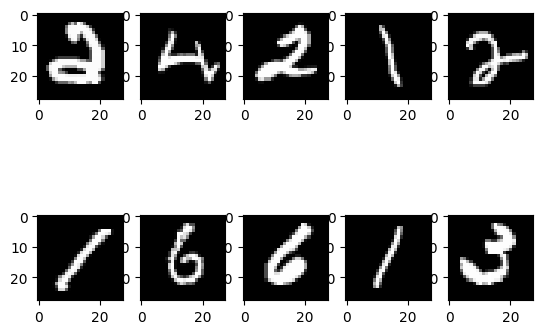

In [6]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(samples[i][0], cmap='gray')
plt.show()

In [7]:
X_train = train_dataset.data
y_train = train_dataset.targets

X_test = test_dataset.data
y_test = test_dataset.targets

### Model verification

In [8]:
rf_model = MnistClassifier(algorithm='rf')
start_time = time.time()
rf_model.train(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = np.mean(y_pred_rf == y_test.numpy())
end_time = time.time()
print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"Training Time: {(end_time - start_time):.2f} seconds")

Training RandomForestMnistClassifier...
Making predictions with RandomForestMnistClassifier...
Random Forest Accuracy: 0.9705
Training Time: 41.37 seconds


In [11]:
cnn_model = MnistClassifier(algorithm='cnn')
start_time = time.time()
cnn_model.train(X_train, y_train, num_epochs=num_epochs, batch_size=batch_size, learning_rate=learning_rate)
y_pred_cnn = cnn_model.predict(X_test).numpy()
cnn_accuracy = np.mean(y_pred_cnn == y_test.numpy())
end_time = time.time()
print(f"CNN Accuracy: {cnn_accuracy}")
print(f"Training Time: {(end_time - start_time):.2f} seconds")

Training CNNClassifier...
Epoch [1/2], Loss: 0.1936
Epoch [2/2], Loss: 0.0344
Making predictions with CNNClassifier...
CNN Accuracy: 0.9715
Training Time: 33.36 seconds


In [12]:
nn_model = MnistClassifier(algorithm='nn')
start_time = time.time()
nn_model.train(X_train, y_train, num_epochs=num_epochs, batch_size=batch_size, learning_rate=learning_rate)
y_pred_nn = nn_model.predict(X_test).numpy()
nn_accuracy = np.mean(y_pred_nn == y_test.numpy())
end_time = time.time()
print(f"NN Accuracy: {nn_accuracy}")
print(f"Training Time: {end_time - start_time}")

Training FeedForwardNN...
Epoch [1/2], Loss: 0.3627
Epoch [2/2], Loss: 0.0039
Making predictions with FeedForwardNN...
NN Accuracy: 0.9517
Training Time: 4.342606544494629


### Input algorithm

In [26]:
algorithm = input("Enter algorithm to predict (rf, cnn, nn): ").strip().lower()

model = MnistClassifier(algorithm=algorithm)

start_time = time.time()
if algorithm == 'rf':
    model.train(X_train, y_train)
    y_pred = model.predict(X_test)
elif algorithm in ['cnn', 'nn']:
    model.train(
        X_train, y_train, 
        num_epochs=num_epochs, 
        batch_size=batch_size, 
        learning_rate=learning_rate
    )
    y_pred = model.predict(X_test).numpy()
else:
    raise ValueError("Invalid algorithm choice. Please choose 'rf', 'cnn', or 'nn'.")

accuracy = np.mean(y_pred == y_test.numpy())
end_time = time.time()
print(f"{algorithm.upper()} Accuracy: {accuracy}")
print(f"{algorithm.upper()} Training Time: {end_time - start_time:.2f} seconds")



Training FeedForwardNN...
Epoch [1/5], Loss: 0.3744
Epoch [2/5], Loss: 0.0390
Epoch [3/5], Loss: 0.0319
Epoch [4/5], Loss: 0.2384
Epoch [5/5], Loss: 0.3830
Making predictions with FeedForwardNN...
NN Accuracy: 0.9521
NN Training Time: 21.44 seconds
